# A2 — GOP vs human phoneme scores

Reads artifacts from Group A. **Does not recompute GOP** (that is A1).

| File | Experiment |
| --- | --- |
| `outputs/A/a1_predictions.csv` | A1 — Traditional GOP scalar |
| `outputs/A/a2_results.json` | A2 — PCC / SCC / MAE / MSE |

```text
python scripts/run_experiment.py --config configs/a_traditional_gop.yaml
```


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "A" / "a2_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "A" / "a2_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "A" / "a2_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "A"
pred = pd.read_csv(OUT / "a1_predictions.csv")
results = json.loads((OUT / "a2_results.json").read_text(encoding="utf-8"))
a1, a2 = results["A1"], results["A2"]
test = pred[pred["split"] == "test"].copy()
train = pred[pred["split"] == "train"].copy()
print("ROOT", ROOT)
print("A1", a1["gop_type"], a1["acoustic_model"], "n_train", a1["n_train"], "n_test", a1["n_test"])
print("A2 test PCC", round(a2["pcc"], 4), "SCC", round(a2["scc"], 4))
print("A2 test MAE", round(a2["mae"], 4), "MSE", round(a2["mse"], 4))

ROOT d:\FSB_MSE\FINAL\GOP-Empirical-Study
A1 standard kaldi_librispeech_m13 n_train 47076 n_test 47369
A2 test PCC 0.3231 SCC 0.3128
A2 test MAE 0.1994 MSE 0.1203


## Scatter: GOP vs human (test)

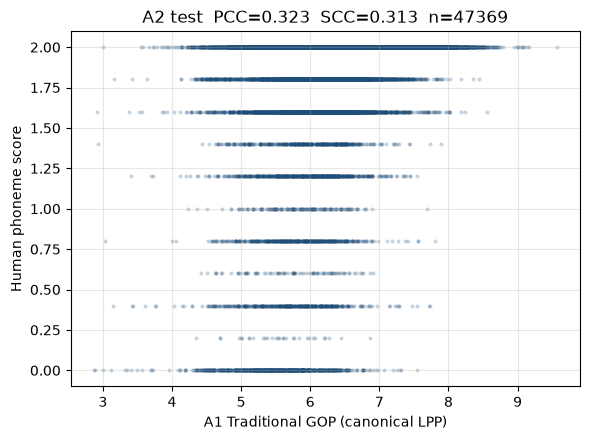

In [2]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(test["gop"], test["human_score"], s=8, alpha=0.25, c="#1f4e79", linewidths=0)
ax.set_xlabel("A1 Traditional GOP (canonical LPP)")
ax.set_ylabel("Human phoneme score")
ax.set_title(
    f"A2 test  PCC={a2['pcc']:.3f}  SCC={a2['scc']:.3f}  n={len(test)}"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "a2_scatter_gop_vs_human.png", dpi=140)
plt.show()

## GOP distribution by human score

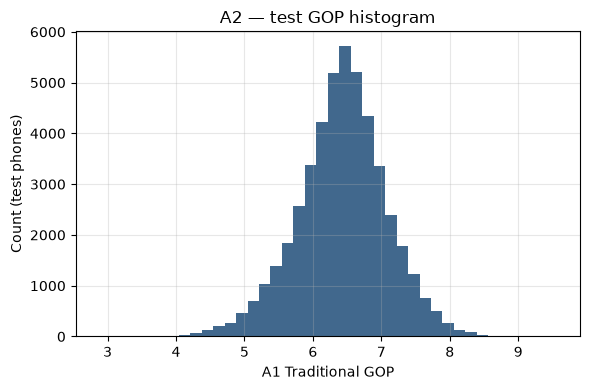

,count,mean,std,median
human_score,,,,
0.0,943,5.500,0.623,5.530
0.2,31,5.562,0.561,5.550
0.4,438,5.697,0.658,5.720
0.6,88,5.766,0.624,5.778
0.8,478,5.821,0.574,5.831
1.0,171,5.852,0.538,5.879
1.2,688,5.921,0.587,5.968
1.4,435,5.965,0.603,6.010
1.6,2456,6.110,0.620,6.158


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(test["gop"], bins=40, color="#1f4e79", alpha=0.85)
ax.set_xlabel("A1 Traditional GOP")
ax.set_ylabel("Count (test phones)")
ax.set_title("A2 — test GOP histogram")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "a2_gop_histogram.png", dpi=140)
plt.show()

display(
    test.groupby("human_score")["gop"]
    .agg(["count", "mean", "std", "median"])
    .round(3)
)

## Extreme cases (lowest / highest GOP on test)

In [4]:
cols = ["utt_id", "word_id", "phone_id", "phone", "gop", "human_score"]
print("Lowest GOP")
display(test.nsmallest(10, "gop")[cols])
print("Highest GOP")
display(test.nlargest(10, "gop")[cols])
print("Low GOP but human>=1.8 (possible false alarm)")
display(test[test["human_score"] >= 1.8].nsmallest(8, "gop")[cols])
print("High GOP but human<=1 (possible miss)")
display(test[test["human_score"] <= 1.0].nlargest(8, "gop")[cols])

Lowest GOP


,utt_id,word_id,phone_id,phone,gop,human_score
80515,96400013,2,5,NG,2.868472,0.0
75531,96080015,5,2,NG,2.879936,0.0
80266,96350025,5,4,NG,2.910065,1.6
67275,930148,4,2,ZH,2.922958,1.4
81121,96470021,2,2,ZH,2.994865,0.0
78971,96290015,2,4,NG,3.002587,2.0
80545,96400016,2,2,ZH,3.037562,0.8
80427,96400007,5,4,NG,3.117708,0.0
75382,96080007,4,6,ZH,3.151017,0.4
91166,11350345,3,4,NG,3.167794,1.8


Highest GOP


,utt_id,word_id,phone_id,phone,gop,human_score
74239,95550134,1,2,N,9.567645,2.0
59251,28920235,6,2,R,9.157851,2.0
58751,27400173,4,2,N,9.131907,2.0
92365,11860361,6,0,L,9.097251,2.0
59538,28970088,2,2,IH,9.074352,2.0
93349,12930028,5,5,N,9.058596,2.0
75024,96010010,6,5,L,9.053079,2.0
49426,14200353,8,2,M,8.998457,2.0
71221,85810152,3,2,N,8.998454,2.0
89306,10610129,3,2,L,8.985056,2.0


Low GOP but human>=1.8 (possible false alarm)


,utt_id,word_id,phone_id,phone,gop,human_score
78971,96290015,2,4,NG,3.002587,2.0
91166,11350345,3,4,NG,3.167794,1.8
91035,11350225,3,2,NG,3.415546,1.8
80947,96470012,5,5,NG,3.548626,2.0
62307,30750074,1,4,NG,3.577763,2.0
76816,96170011,3,2,NG,3.633473,1.8
76852,96170012,5,4,NG,3.670737,2.0
63545,50150116,4,2,NG,3.726683,2.0


High GOP but human<=1 (possible miss)


,utt_id,word_id,phone_id,phone,gop,human_score
92417,11860373,1,5,K,7.798639,0.8
74986,96010009,4,4,N,7.725759,0.4
92415,11860373,1,3,T,7.719091,0.4
49347,14200296,3,0,AH,7.694144,1.0
82681,1330143,4,2,V,7.559800,0.8
80676,96400024,4,3,P,7.552831,0.8
49695,14220140,5,3,D,7.550469,0.0
76774,96170009,1,1,L,7.545771,0.4
